# Training and optimizing a BDT to separate double charm background

### Loading the data from disk (as saved by Prepare-training-data)

In [11]:
import optuna
import xgboost as xgb
import sklearn
import numpy as np
import matplotlib.pyplot as plt

In [12]:
%matplotlib inline
plt.rcParams["figure.figsize"] = (15,8)
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [13]:
data = np.load("bdt_training_data.npz")
Xtrain_scaled = data['Xtrain_scaled']
ytrain = data['ytrain']
Xvalid_scaled = data['Xvalid_scaled']
yvalid = data['yvalid']
Xtest_scaled = data['Xtest_scaled']
ytest = data['ytest']
train_columns = data['train_columns']
print(f"Ratio bkg/sig:{ np.count_nonzero(ytrain == 0) / np.count_nonzero(ytrain)}")

Ratio bkg/sig:50.82315420188168


In [14]:
Xtrain_scaled.shape

(324983, 23)

In [15]:
Xvalid_scaled.shape

(162408, 23)

In [16]:
Xtest_scaled.shape

(162408, 23)

## 1. Training an XGBoost classifier

In [17]:
ratio = np.count_nonzero(ytrain == 0) / np.count_nonzero(ytrain)
print(ratio)

50.82315420188168


In [28]:
# model = xgb.XGBClassifier( eval_metric='logloss', 
#                           n_estimators=180, 
#                           eta=0.08, 
#                           #gamma=0.10,
#                           #reg_lambda=4.34,
#                           scale_pos_weight=ratio, 
#                           max_depth=3, 
#                           random_state=42, tree_method="gpu_hist", verbosity=1, seed=42)
# model
model = xgb.XGBClassifier( eval_metric='logloss', 
                          n_estimators=120, 
                          eta=0.10, 
                          #gamma=0.10,
                          #reg_lambda=4.34,
                          scale_pos_weight=ratio, 
                          max_depth=3, 
                          random_state=42, tree_method="gpu_hist", verbosity=1, seed=42)
model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eta=0.1, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=120, n_jobs=None,
              num_parallel_tree=None, predictor=None, ...)

In [29]:
%%time
evalset = [(Xtrain_scaled, ytrain), (Xvalid_scaled, yvalid)]
res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset, verbose=True)

[0]	validation_0-logloss:0.67048	validation_1-logloss:0.67032
[1]	validation_0-logloss:0.65245	validation_1-logloss:0.65208
[2]	validation_0-logloss:0.63683	validation_1-logloss:0.63639
[3]	validation_0-logloss:0.62269	validation_1-logloss:0.62222
[4]	validation_0-logloss:0.61050	validation_1-logloss:0.60998
[5]	validation_0-logloss:0.59873	validation_1-logloss:0.59815
[6]	validation_0-logloss:0.58829	validation_1-logloss:0.58773
[7]	validation_0-logloss:0.57932	validation_1-logloss:0.57866
[8]	validation_0-logloss:0.57034	validation_1-logloss:0.56963
[9]	validation_0-logloss:0.56175	validation_1-logloss:0.56097
[10]	validation_0-logloss:0.55479	validation_1-logloss:0.55404
[11]	validation_0-logloss:0.54753	validation_1-logloss:0.54675
[12]	validation_0-logloss:0.54179	validation_1-logloss:0.54097
[13]	validation_0-logloss:0.53629	validation_1-logloss:0.53554
[14]	validation_0-logloss:0.53100	validation_1-logloss:0.53022
[15]	validation_0-logloss:0.52554	validation_1-logloss:0.52474
[1

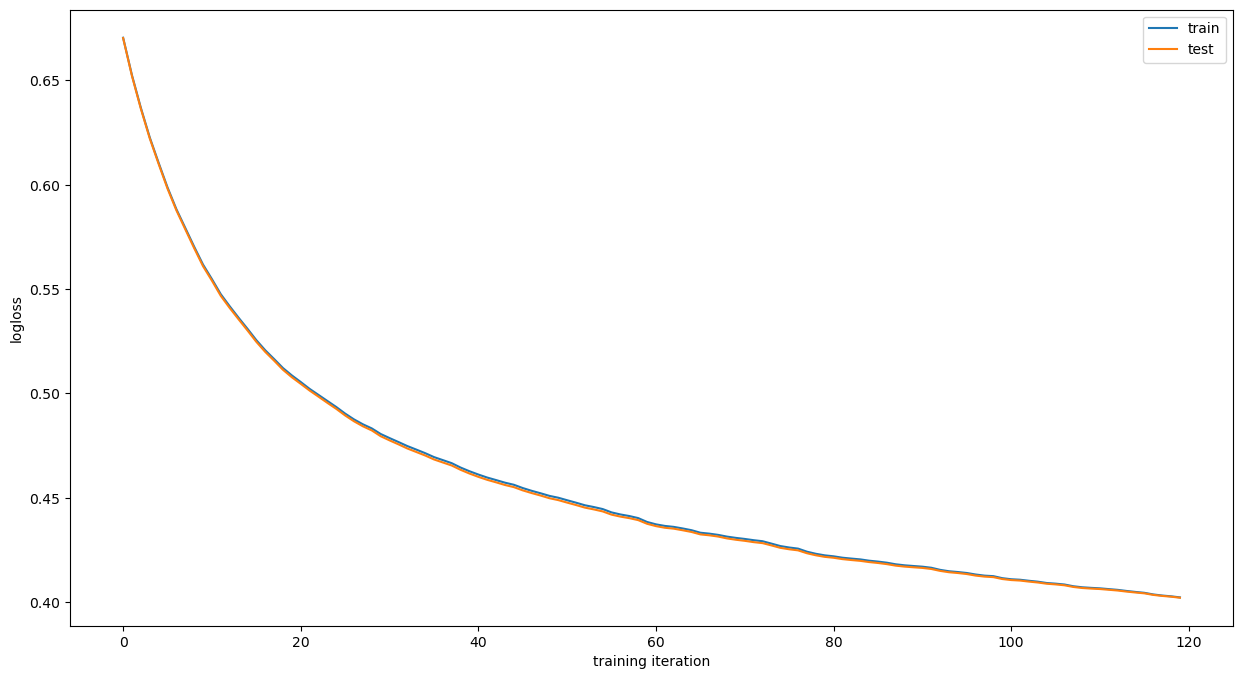

In [30]:
results = model.evals_result()
# plot learning curves
plt.plot(results['validation_0']['logloss'], label='train')
plt.plot(results['validation_1']['logloss'], label='test')
# show the legend
plt.legend()
# show the plot
plt.ylabel("logloss")
plt.xlabel("training iteration")
plt.show()

In [31]:
#import joblib
#joblib.dump(xgbclass, "bdt_all_42.pkl")

### Checking the classifier

0.8920567780093596


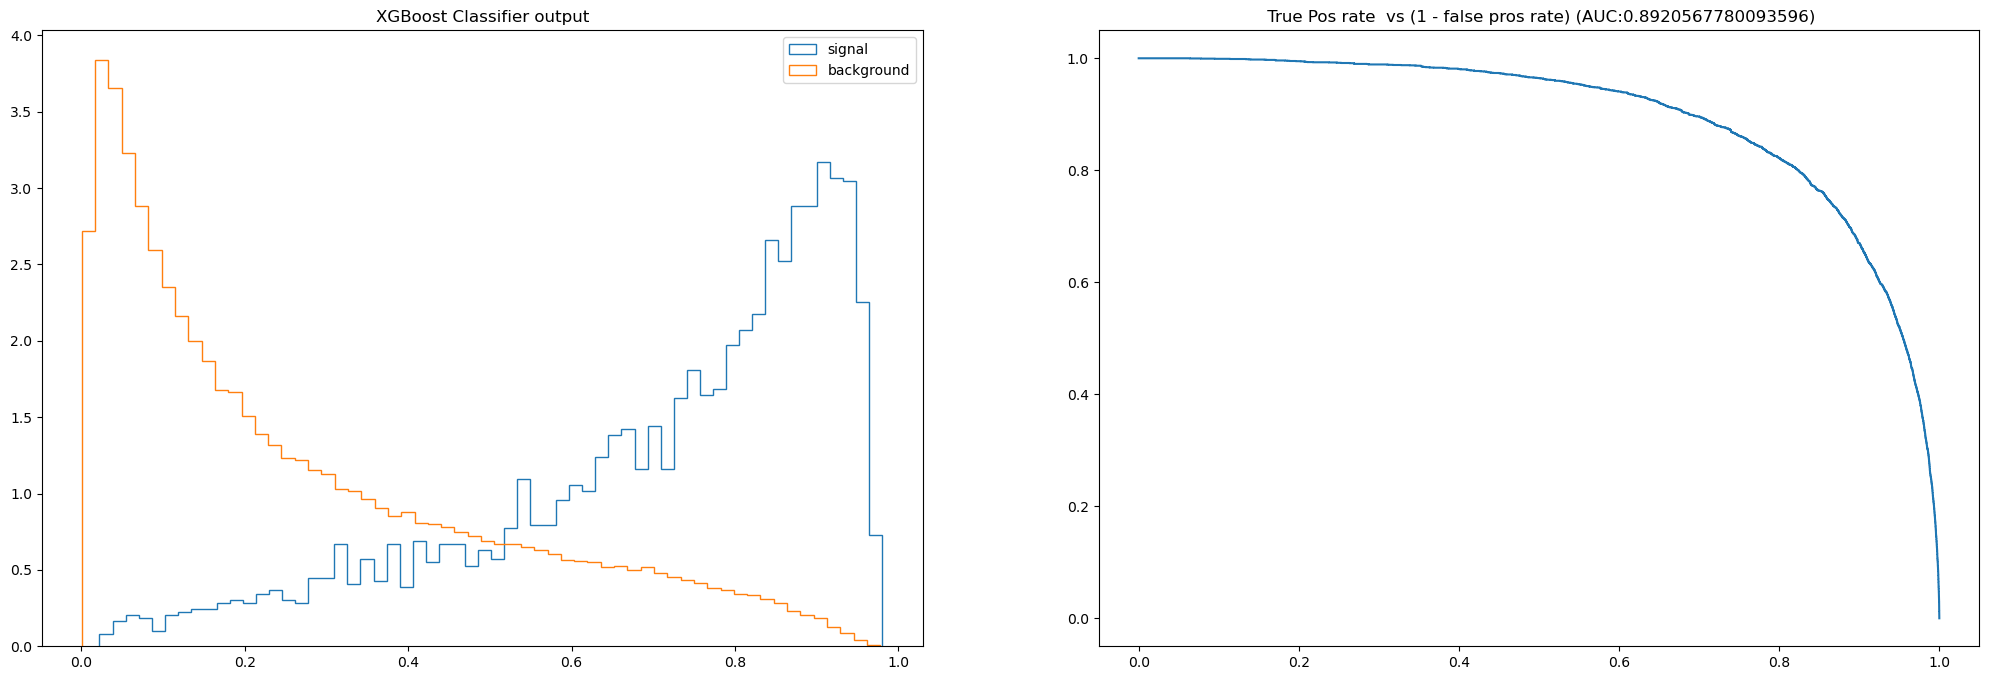

In [32]:
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import roc_curve, auc
yscore = model.predict_proba(Xtest_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))

# ROC curve 
#RocCurveDisplay.from_estimator(classifier, Xtest, ytest).plot(ax=ax2)
fpr, tpr, _ = roc_curve(ytest, yscore[:,1])
roc_auc = auc(fpr, tpr)
ax2.plot(1 - fpr, tpr)
ax2.set_title(f" True Pos rate  vs (1 - false pros rate) (AUC:{roc_auc})")
print(roc_auc)

# Classifier output
ax1.set_title(f"XGBoost Classifier output")
t = 'step'
n, bins, p = ax1.hist(yscore[ytest == 1, 1], bins=60, histtype=t, label='signal', density=True);
ax1.hist(yscore[ytest == 0, 1], bins=len(bins)-1, histtype=t, label='background', density=True);
ax1.legend();

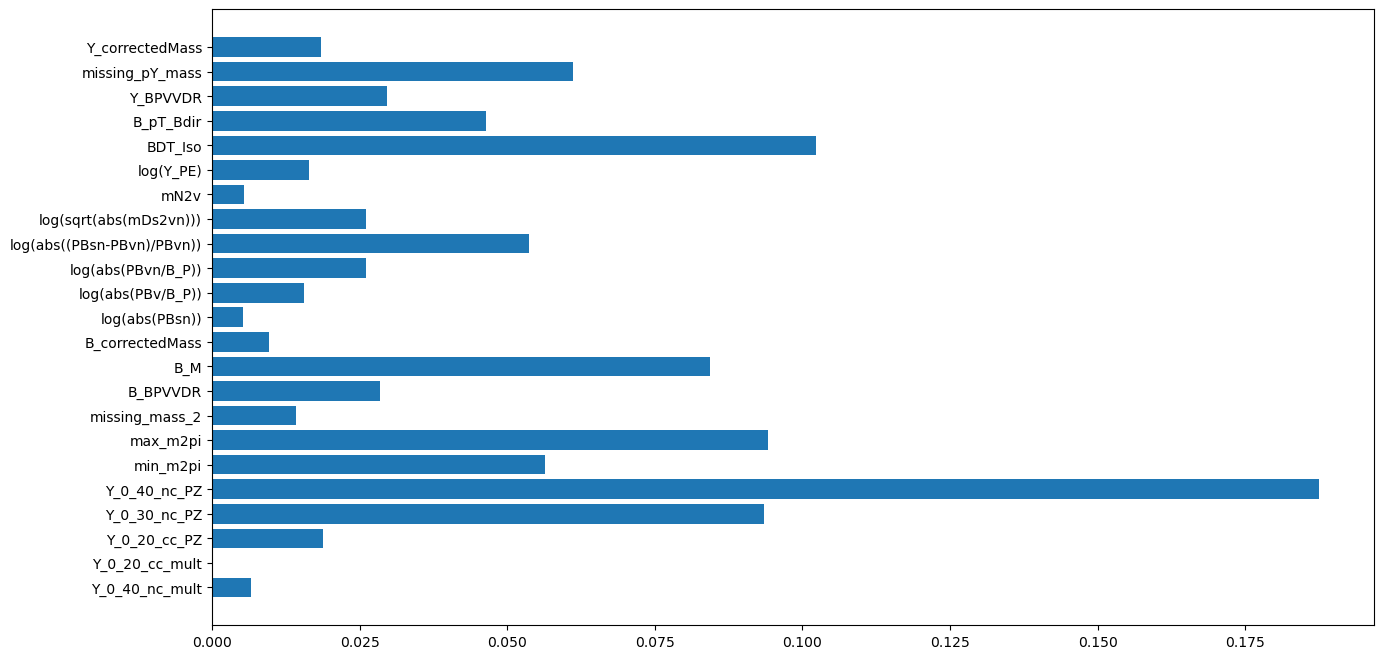

In [33]:
plt.barh(train_columns, model.feature_importances_);

In [34]:
from scipy.stats import ks_2samp

def get_bdt_reponse_similarity(clf, X_train, y_train, X_test, y_test):

    # Getting the BDT response
    train_sig = clf.predict_proba(X_train[y_train==1])[:,1]
    train_bkg = clf.predict_proba(X_train[y_train==0])[:,1]
    test_sig = clf.predict_proba(X_test[y_test==1])[:,1]
    test_bkg = clf.predict_proba(X_test[y_test==0])[:,1]
    
    ks_sig = ks_2samp(train_sig, test_sig, alternative='two-sided')
    ks_bkg = ks_2samp(train_bkg, test_bkg, alternative='two-sided')
    
    return ks_sig, ks_bkg
    
ks, kb = get_bdt_reponse_similarity(model, Xtrain_scaled, ytrain, Xtest_scaled, ytest)
print(ks.statistic)
print(kb.statistic)


0.0430295239458281
0.0028222707885193765


4


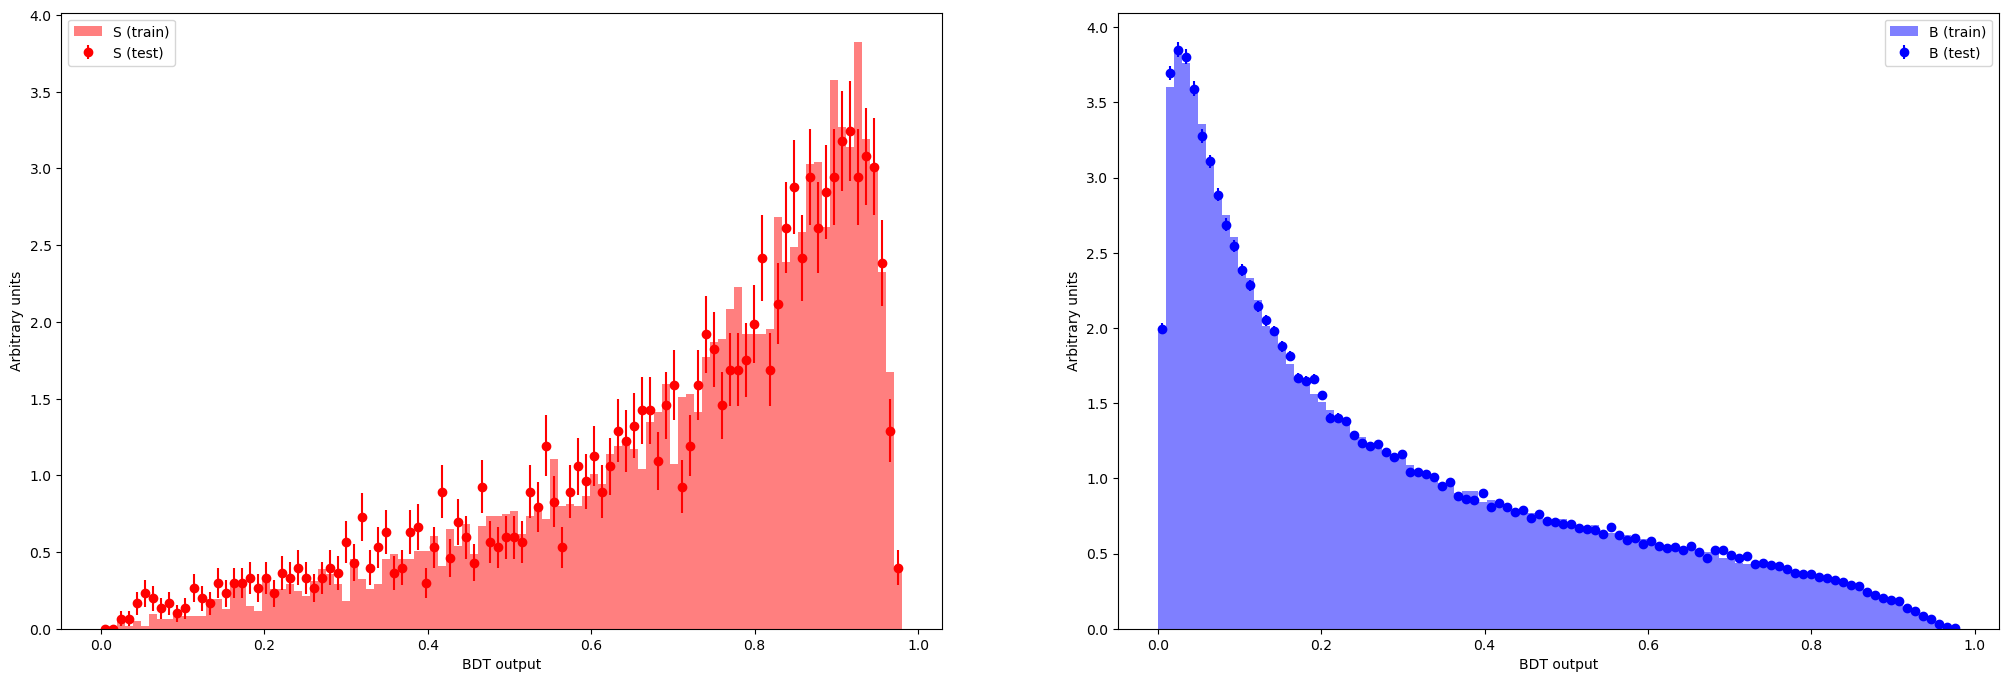

In [35]:
def compare_train_test(clf, X_train, y_train, X_test, y_test, bins=100):
    ''' Taken from Tim Head's recipe: https://betatim.github.io/posts/sklearn-for-TMVA-users/ '''
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 8))
    decisions = []
    for X,y in ((X_train, y_train), (X_test, y_test)):
        d1 = clf.predict_proba(X[y==1])[:,1]
        d2 = clf.predict_proba(X[y==0])[:,1]
        decisions += [d1, d2]
        
    print(len(decisions))
        
    low = min(np.min(d) for d in decisions)
    high = max(np.max(d) for d in decisions)
    low_high = (low,high)
    
    ax1.hist(decisions[0],
             color='r', alpha=0.5, range=low_high, bins=bins,
             histtype='stepfilled', density=True,
             label='S (train)')
    ax2.hist(decisions[1],
             color='b', alpha=0.5, range=low_high, bins=bins,
             histtype='stepfilled', density=True,
             label='B (train)')

    
    hist, bins = np.histogram(decisions[2],
                              bins=bins, range=low_high, density=True)
    scale = len(decisions[2]) / sum(hist)
    err = np.sqrt(hist * scale) / scale
    
    width = (bins[1] - bins[0])
    center = (bins[:-1] + bins[1:]) / 2
    ax1.errorbar(center, hist, yerr=err, fmt='o', c='r', label='S (test)')
    
    hist, bins = np.histogram(decisions[3],
                              bins=bins, range=low_high, density=True)

    scale = len(decisions[3]) / sum(hist)
    
    err = np.sqrt(hist * scale) / scale

    ax2.errorbar(center, hist, yerr=err, fmt='o', c='b', label='B (test)')

    ax1.set_xlabel("BDT output")
    ax1.set_ylabel("Arbitrary units")
    ax1.legend(loc='best')

    ax2.set_xlabel("BDT output")
    ax2.set_ylabel("Arbitrary units")
    ax2.legend(loc='best')

    
compare_train_test(model, Xtrain_scaled, ytrain, Xtest_scaled, ytest)


## Using folds for validation

In [37]:
%%time
from sklearn.model_selection import cross_val_score
cvs = cross_val_score(model, Xtrain_scaled, ytrain, cv=5, scoring='roc_auc')
cvs

CPU times: user 8.4 s, sys: 52.1 ms, total: 8.45 s
Wall time: 1.91 s


array([0.89115032, 0.89607575, 0.88873548, 0.89913498, 0.89121803])

In [38]:
print(f"Mean   : {np.mean(cvs):.5f}")
print(f"Stddev : {np.std(cvs):.5f}")

Mean   : 0.89326
Stddev : 0.00378


# Optimizer for Optuna using the scikit learn interface

In [18]:
import optuna
import xgboost as xgb
import sklearn

In [20]:
def objective(trial):
    model = xgb.XGBClassifier(eval_metric='logloss', 
                              n_estimators=trial.suggest_int("n_estimators", 100, 300, step=25), 
                              eta=trial.suggest_float("eta", 0.01, 0.10, step=0.01), # 0.03, 
                              scale_pos_weight=ratio, 
                              max_depth=4,#trial.suggest_int("max_depth", 3, 6), #4
                              #gamma=trial.suggest_float("gamma", 0, 0.2),
                              #reg_lambda=trial.suggest_float("lambda", 1.0, 10.0),
                              random_state=42, 
                              tree_method="gpu_hist",
                             verbosity=0)
    evalset = [(Xtrain_scaled, ytrain), (Xvalid_scaled, yvalid)]
    res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset, verbose=False)
    yscore = model.predict_proba(Xvalid_scaled)
    fpr, tpr, _ = roc_curve(yvalid, yscore[:,1])
    roc_auc = auc(fpr, tpr)
    ks, kb = get_bdt_reponse_similarity(model, Xtrain_scaled, ytrain, Xtest_scaled, ytest)
    return roc_auc, np.log(ks.statistic * kb.statistic)

In [21]:

study_name = "ks_sklearn_bdt2"
study = optuna.create_study(directions=["maximize", "minimize"], study_name=study_name, storage="sqlite:///{}.db".format(study_name), load_if_exists=True)
study.optimize(objective, n_trials=100)
print(study.best_trials)

[I 2023-09-09 21:01:02,142] Using an existing study with name 'ks_sklearn_bdt2' instead of creating a new one.
[I 2023-09-09 21:01:03,772] Trial 1090 finished with values: [0.8702801031630805, -9.330849931163856] and parameters: {'n_estimators': 200, 'eta': 0.01}. 
[I 2023-09-09 21:01:05,016] Trial 1091 finished with values: [0.9050115016219861, -8.12302064374274] and parameters: {'n_estimators': 225, 'eta': 0.09}. 
[I 2023-09-09 21:01:06,069] Trial 1092 finished with values: [0.8930619550296792, -9.00310868743223] and parameters: {'n_estimators': 150, 'eta': 0.04}. 
[I 2023-09-09 21:01:06,937] Trial 1093 finished with values: [0.8978896942885329, -8.901623283693503] and parameters: {'n_estimators': 100, 'eta': 0.08}. 
[I 2023-09-09 21:01:07,900] Trial 1094 finished with values: [0.9006511316278922, -8.701023548623612] and parameters: {'n_estimators': 125, 'eta': 0.08}. 
[I 2023-09-09 21:01:09,239] Trial 1095 finished with values: [0.9037588857094423, -8.310368323356366] and parameters

[I 2023-09-09 21:02:06,168] Trial 1141 finished with values: [0.9049774747058379, -8.110987767321545] and parameters: {'n_estimators': 300, 'eta': 0.06999999999999999}. 
[I 2023-09-09 21:02:07,072] Trial 1142 finished with values: [0.8892051022721182, -9.20443616077239] and parameters: {'n_estimators': 100, 'eta': 0.05}. 
[I 2023-09-09 21:02:08,295] Trial 1143 finished with values: [0.8702801031630805, -9.330849931163856] and parameters: {'n_estimators': 200, 'eta': 0.01}. 
[I 2023-09-09 21:02:09,182] Trial 1144 finished with values: [0.8584424838055228, -9.369196258638384] and parameters: {'n_estimators': 100, 'eta': 0.01}. 
[I 2023-09-09 21:02:10,461] Trial 1145 finished with values: [0.8866435397999746, -9.173980552021556] and parameters: {'n_estimators': 225, 'eta': 0.02}. 
[I 2023-09-09 21:02:11,896] Trial 1146 finished with values: [0.9044440321840435, -8.263349144394995] and parameters: {'n_estimators': 275, 'eta': 0.060000000000000005}. 
[I 2023-09-09 21:02:12,820] Trial 1147 f

[FrozenTrial(number=8, state=TrialState.COMPLETE, values=[0.8915874495477827, -9.411441963413914], datetime_start=datetime.datetime(2023, 9, 8, 22, 56, 45, 217648), datetime_complete=datetime.datetime(2023, 9, 8, 22, 56, 46, 14674), params={'n_estimators': 150, 'eta': 0.09, 'max_depth': 3}, user_attrs={}, system_attrs={'nsga2:generation': 0}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=300, log=False, low=100, step=25), 'eta': FloatDistribution(high=0.1, log=False, low=0.01, step=0.01), 'max_depth': IntDistribution(high=6, log=False, low=3, step=1)}, trial_id=9, value=None), FrozenTrial(number=13, state=TrialState.COMPLETE, values=[0.892994068414844, -9.37225608730992], datetime_start=datetime.datetime(2023, 9, 8, 22, 56, 51, 172144), datetime_complete=datetime.datetime(2023, 9, 8, 22, 56, 52, 49182), params={'n_estimators': 175, 'eta': 0.08, 'max_depth': 3}, user_attrs={}, system_attrs={'nsga2:generation': 0}, intermediate_values={}, distributions={'n_e

In [181]:
hd = study.trials_dataframe()

In [191]:
hd.to_pickle("study_1000.pkl") 

In [192]:
ORIGINhd

,number,values_0,values_1,datetime_start,datetime_complete,duration,params_eta,params_max_depth,params_n_estimators,system_attrs_nsga2:generation,state
0,0,0.894527,-9.160386,2023-09-08 22:56:35.415000,2023-09-08 22:56:36.413996,0 days 00:00:00.998996,0.08,3,200,0,COMPLETE
1,1,0.875143,-8.807550,2023-09-08 22:56:36.448048,2023-09-08 22:56:38.083792,0 days 00:00:01.635744,0.01,6,225,0,COMPLETE
2,2,0.877878,-9.044309,2023-09-08 22:56:38.114348,2023-09-08 22:56:38.964433,0 days 00:00:00.850085,0.03,5,100,0,COMPLETE
3,3,0.875472,-9.680519,2023-09-08 22:56:39.003222,2023-09-08 22:56:40.092742,0 days 00:00:01.089520,0.02,3,275,0,COMPLETE
4,4,0.900081,-7.617142,2023-09-08 22:56:40.122110,2023-09-08 22:56:41.829917,0 days 00:00:01.707807,0.07,5,300,0,COMPLETE
...,...,...,...,...,...,...,...,...,...,...,...
995,995,0.885041,-9.667891,2023-09-08 23:16:58.661895,2023-09-08 23:16:59.474565,0 days 00:00:00.812670,0.06,3,150,19,COMPLETE
996,996,0.883697,-9.624579,2023-09-08 23:16:59.506504,2023-09-08 23:17:00.426302,0 days 00:00:00.919798,0.04,3,200,19,COMPLETE
997,997,0.897446,-9.082560,2023-09-08 23:17:00.459842,2023-09-08 23:17:01.562140,0 days 00:00:01.102298,0.09,3,275,19,COMPLETE
998,998,0.891691,-8.678528,2023-09-08 23:17:01.595292,2023-09-08 23:17:03.344652,0 days 00:00:01.749360,0.02,5,300,19,COMPLETE


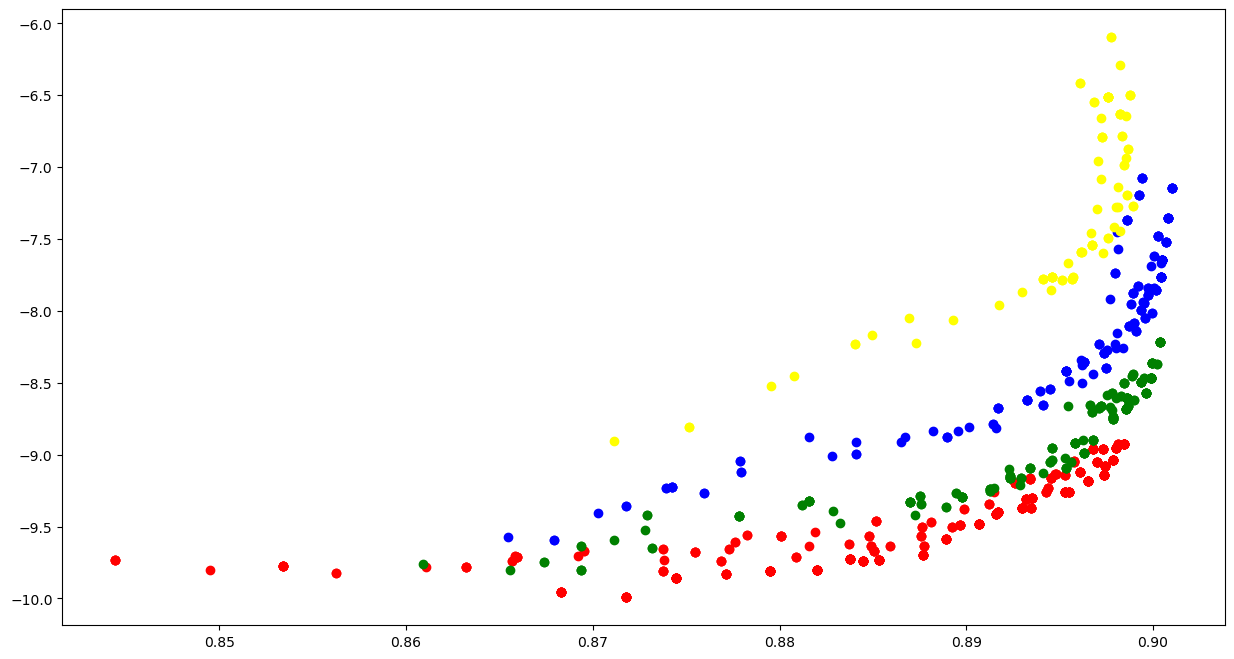

In [189]:
hd3 = hd.query("params_max_depth==3")
plt.scatter(hd3['values_0'], hd3['values_1'], c='red')
hd4 = hd.query("params_max_depth==4")
plt.scatter(hd4['values_0'], hd4['values_1'], c='green')
hd5 = hd.query("params_max_depth==5")
plt.scatter(hd5['values_0'], hd5['values_1'], c='blue')
hd6 = hd.query("params_max_depth==6")
plt.scatter(hd6['values_0'], hd6['values_1'], c='yellow')

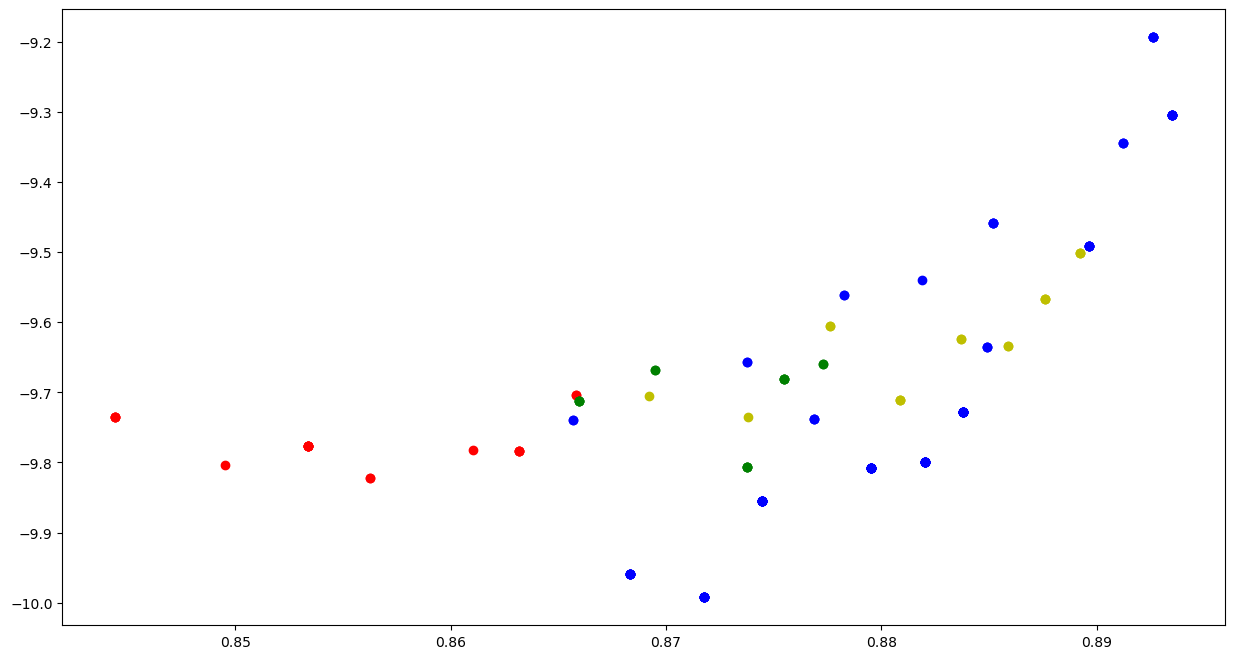

In [194]:
hd3 = hd.query("params_max_depth==3")
etaval = 0.01
for c in ['r', 'g', 'b', 'y', 'b']:
    hdt = hd3.query(f"abs(params_eta - {etaval}) < 1e-6")
    plt.scatter(hdt['values_0'], hdt['values_1'], c=c)
    etaval += 0.01


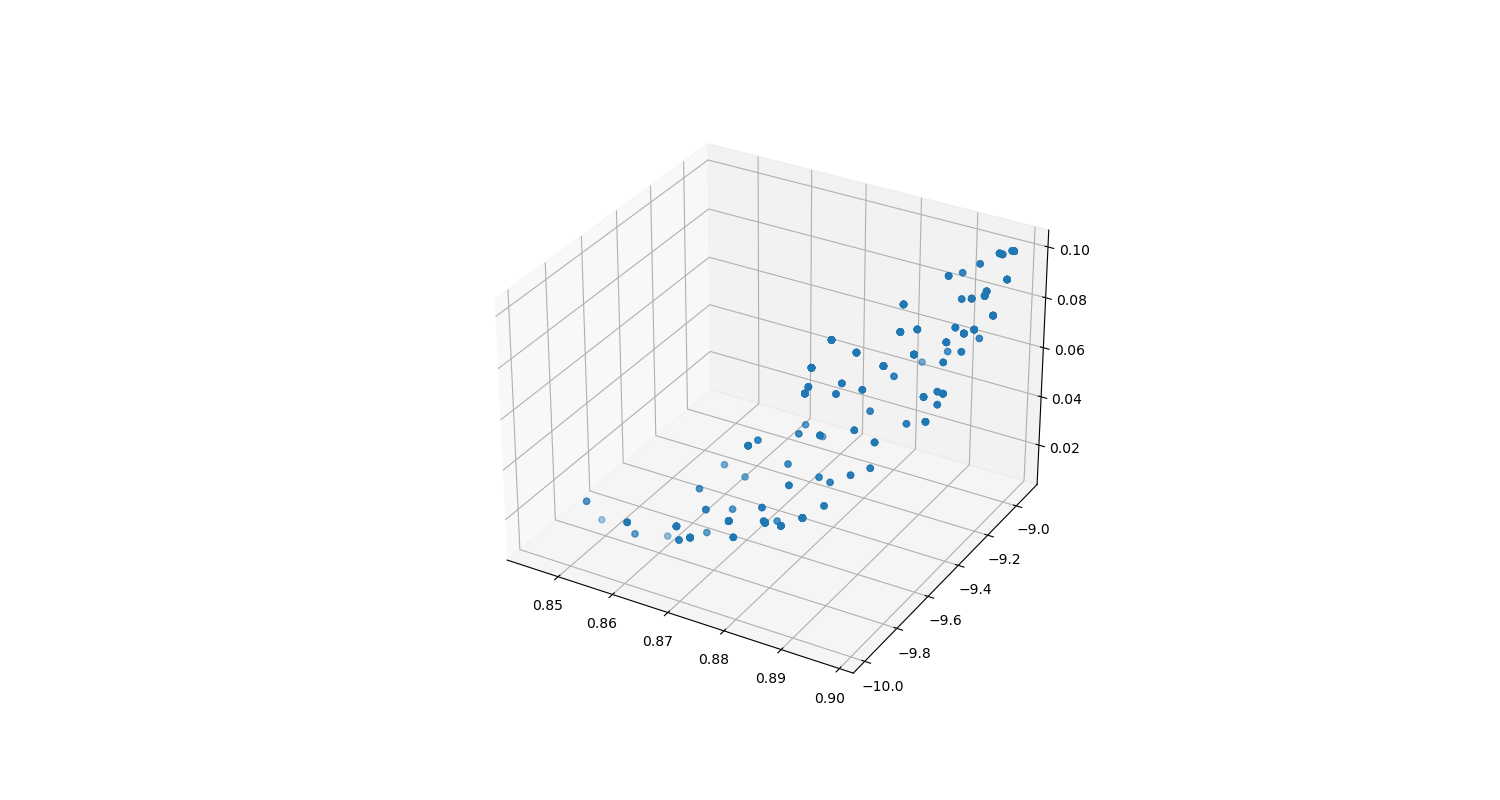

In [217]:
%matplotlib widget


hd3 = hd.query("params_max_depth==3")
ax = plt.figure().add_subplot(projection='3d')
ax.scatter(hd3['values_0'], hd3['values_1'], hd3["params_eta"])


In [200]:
from mpl_toolkits.mplot3d import axes3d
X, Y, Z = axes3d.get_test_data(0.05)

In [207]:
Z

array([[-0.00982064, -0.0113957 , -0.01319036, ..., -0.01522953,
        -0.01319036, -0.0113957 ],
       [-0.0113957 , -0.01322338, -0.01530587, ..., -0.01767209,
        -0.01530587, -0.01322338],
       [-0.01319036, -0.01530587, -0.01771632, ..., -0.02045518,
        -0.01771632, -0.01530587],
       ...,
       [-0.01200234, -0.01414685, -0.01660867, ...,  0.02918791,
         0.03019517,  0.03085725],
       [-0.01097235, -0.01288301, -0.01507265, ...,  0.01583738,
         0.01709512,  0.01804782],
       [-0.00988645, -0.01157475, -0.01350698, ...,  0.00702321,
         0.0083816 ,  0.00947216]])

# Optimizing the search parameters with Optuna

In [ ]:
np.savez("bdt_training_data", Xtrain_scaled=Xtrain_scaled, ytrain=ytrain, Xtest_scaled=Xtest_scaled, ytest=ytest)

In [ ]:
data = np.load("bdt_training_data.npz")
xtr = data['Xtrain_scaled']
ytr = data['ytrain']
xte = data['Xtest_scaled']
xte = data['ytest']


In [ ]:
np.count_nonzero(ytr)

In [ ]:
ytr.shape

In [ ]:
np.count_nonzero(ytr == 0)

In [ ]:
np.count_nonzero(ytr == 0) / np.count_nonzero(ytr)

In [ ]:
import optuna
import xgboost as xgb
import sklearn

In [ ]:
# model = xgb.XGBClassifier( eval_metric='logloss', 
#                           n_estimators=300, eta=0.03, scale_pos_weight=ratio, max_depth=4, random_state=42, tree_method="gpu_hist")
# xgbclass = make_pipeline(scaler, model)

dtrain = xgb.DMatrix(Xtrain_scaled, label=ytrain)
dvalid = xgb.DMatrix(Xtest_scaled, label=ytest)
    
#     parameters = {
#     'learning_rate': [0.1, 0.05],#, 0.05],
#     'max_depth': range (2, 5, 1),
#     'n_estimators': [ 60, 200,],# 500, 1000 ],
#     'num_boost_round': [60, 250]#, 500, 1000]  
    
param = {
    "eval_metric": "logloss",
    "verbosity": 2,
    #"objective": "binary:logistic",
    "booster": "gbtree",
    "eta":0.03,
    "scale_pos_weight": ratio,
    "max_depth":4,
    "random_state": 42,
    "tree_method": "gpu_hist",
}

bst = xgb.train(param, dtrain, num_boost_round=300)
yscore = bst.predict(dvalid)
fpr, tpr, _ = roc_curve(ytest, yscore)
roc_auc = auc(fpr, tpr)
print(f"AUC:{roc_auc}")

In [ ]:
#evalset = [(Xtrain_scaled, ytrain), (Xtest_scaled, ytest)]
#res = model.fit(Xtrain_scaled, ytrain, eval_set=evalset)

def objective(trial):

    dtrain = xgb.DMatrix(Xtrain_scaled, label=ytrain)
    dvalid = xgb.DMatrix(Xtest_scaled, label=ytest)
    
#     parameters = {
#     'learning_rate': [0.1, 0.05],#, 0.05],
#     'max_depth': range (2, 5, 1),
#     'n_estimators': [ 60, 200,],# 500, 1000 ],
#     'num_boost_round': [60, 250]#, 500, 1000]  
    
    param = {
        "verbosity": 0,
        "objective": "binary:logistic",
        # defines booster, gblinear for linear functions.
        "booster": trial.suggest_categorical("booster", ["gbtree", "gblinear", "dart"]),
        # L2 regularization weight.
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True),
        # L1 regularization weight.
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        # sampling ratio for training data.
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        # sampling according to each tree.
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
        "tree_method": "gpu_hist",
    }

    if param["booster"] in ["gbtree", "dart"]:
        # maximum depth of the tree, signifies complexity of the tree.
        param["max_depth"] = trial.suggest_int("max_depth", 1, 9, step=2)
        # minimum child weight, larger the term more conservative the tree.
        param["min_child_weight"] = trial.suggest_int("min_child_weight", 2, 10)
        param["eta"] = trial.suggest_float("eta", 1e-8, 1.0, log=True)
        # defines how selective algorithm is.
        param["gamma"] = trial.suggest_float("gamma", 1e-8, 1.0, log=True)
        param["grow_policy"] = trial.suggest_categorical("grow_policy", ["depthwise", "lossguide"])

    if param["booster"] == "dart":
        param["sample_type"] = trial.suggest_categorical("sample_type", ["uniform", "weighted"])
        param["normalize_type"] = trial.suggest_categorical("normalize_type", ["tree", "forest"])
        param["rate_drop"] = trial.suggest_float("rate_drop", 1e-8, 1.0, log=True)
        param["skip_drop"] = trial.suggest_float("skip_drop", 1e-8, 1.0, log=True)

    bst = xgb.train(param, dtrain, num_boost_round= trial.suggest_int("num_boost_round", 100, 800))
    yscore = bst.predict(dvalid)
    fpr, tpr, _ = roc_curve(ytest, yscore)
    roc_auc = auc(fpr, tpr)
    print(f"AUC:{roc_auc}")
    return roc_auc

#     preds = bst.predict(dvalid)
#     pred_labels = np.rint(preds)
#     accuracy = sklearn.metrics.accuracy_score(ytest, pred_labels)
#     return accuracy


In [ ]:
study = optuna.create_study(direction="maximize", study_name="bdt", storage="sqlite:///{}.db".format("BDT"), load_if_exists=True)
study.optimize(objective, n_trials=100)
print(study.best_trial)

c.f. https://neptune.ai/blog/xgboost-everything-you-need-to-know